# nb03 — Does regime skill turn into better portfolios?

Phase 5 of `llm-regime-allocator`. nb02 showed that Sonnet 5.5, reading a **blinded** context pack, forecasts the next-quarter growth × inflation regime better than uniform and than ML on the same inputs. Here those probabilities drive allocations. Everything is read from `python scripts/run_regime_bl.py` output; **no API calls**.

**Setup.** Monthly rebalancing at month-end close, 2007-12 → 2026-05, investable SPY EEM IEF TIP HYG DBC GLD BIL, costs 2.5 bps on traded notional, Sharpe in excess of BIL.

**Two ways to turn probabilities p into weights**
1. **Playbook:** w = Σₖ pₖ · playbookₖ — four fixed regime portfolios set ex ante in `configs/strategy.toml`.
2. **Black-Litterman views** around the strategic reference portfolio (P = I, Ω = He-Litterman / κ, κ = 1 − H(p)/ln 4, so diffuse probabilities ⇒ weak views):
   * **5a, pre-registered:** Q = Σₖ pₖ μₖ, μₖ = shrunk historical mean return of each asset in regime k (point-in-time).
   * **5b, post-hoc (declared after 5a failed):** Q = δΣ(p · playbook), the returns implied by the probability-weighted playbook.

**Every forecaster goes through the same machinery**, including two references that bracket it:
* **uniform** (25% each): the control — identical machinery, zero information.
* **oracle**: the realised regime — a look-ahead *ceiling*, not a strategy.
Sonnet `raw` and `raw + date` are shown only to price contamination (nb02); `blinded` is the main variant.

In [1]:
import sys
sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from lra.evaluation import monthly_excess, sharpe_diff_ci
P5 = Path('../results/phase5')
C = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
INK, MUTED = '#0b0b0b', '#52514e'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2,
                     'axes.edgecolor': MUTED, 'text.color': INK})
met = pd.read_csv(P5 / 'metrics.csv')
daily = pd.read_csv(P5 / 'daily_returns.csv', parse_dates=[0], index_col=0)
views = pd.read_csv(P5 / 'views.csv', parse_dates=['date'])
bil = pd.read_csv('../data/etf_prices.csv', parse_dates=['date'], index_col='date')['BIL'].pct_change()
mex = monthly_excess(daily, bil)
head = met[met.cost_bps == 2.5].set_index('strategy')
NAMES = {'llm_sonnet_blinded': 'Sonnet blinded', 'llm_sonnet_raw': 'Sonnet raw (contaminated)',
         'llm_sonnet_dated': 'Sonnet raw + date (contaminated)', 'ml_logit': 'ML logit raw',
         'ml_gbt': 'ML GBT raw', 'ml_logit_blinded': 'ML logit blinded', 'ml_gbt_blinded': 'ML GBT blinded',
         'climatology': 'climatology', 'uniform': 'uniform (control)', 'oracle': 'oracle (ceiling)'}
def family(prefix):
    t = head.loc[[f'{prefix}__{k}' for k in NAMES]].rename(index=lambda s: NAMES[s.split('__')[1]])
    return t[['ann_return', 'ann_vol', 'sharpe', 'max_drawdown', 'turnover_per_year']].round(3)
bench = head.loc[['sixty_forty', 'bl_equilibrium', 'bl_momentum'],
                 ['ann_return', 'ann_vol', 'sharpe', 'max_drawdown', 'turnover_per_year']].round(3)
bench

,ann_return,ann_vol,sharpe,max_drawdown,turnover_per_year
strategy,,,,,
sixty_forty,0.083,0.111,0.655,-0.319,0.110
bl_equilibrium,0.068,0.102,0.568,-0.316,0.129
bl_momentum,0.091,0.164,0.535,-0.348,2.763


## 1. Playbooks

The simplest mapping: probabilities blend four fixed portfolios.

In [2]:
family('playbook').sort_values('sharpe', ascending=False)

,ann_return,ann_vol,sharpe,max_drawdown,turnover_per_year
strategy,,,,,
oracle (ceiling),0.092,0.082,0.961,-0.143,1.764
Sonnet raw + date (contaminated),0.070,0.071,0.808,-0.138,0.698
Sonnet raw (contaminated),0.069,0.073,0.772,-0.162,0.806
Sonnet blinded,0.068,0.073,0.756,-0.157,0.870
ML GBT raw,0.068,0.074,0.752,-0.183,1.506
ML logit raw,0.064,0.081,0.636,-0.259,1.204
uniform (control),0.061,0.081,0.610,-0.261,0.134
ML GBT blinded,0.059,0.080,0.587,-0.269,1.398
climatology,0.059,0.082,0.575,-0.283,0.142


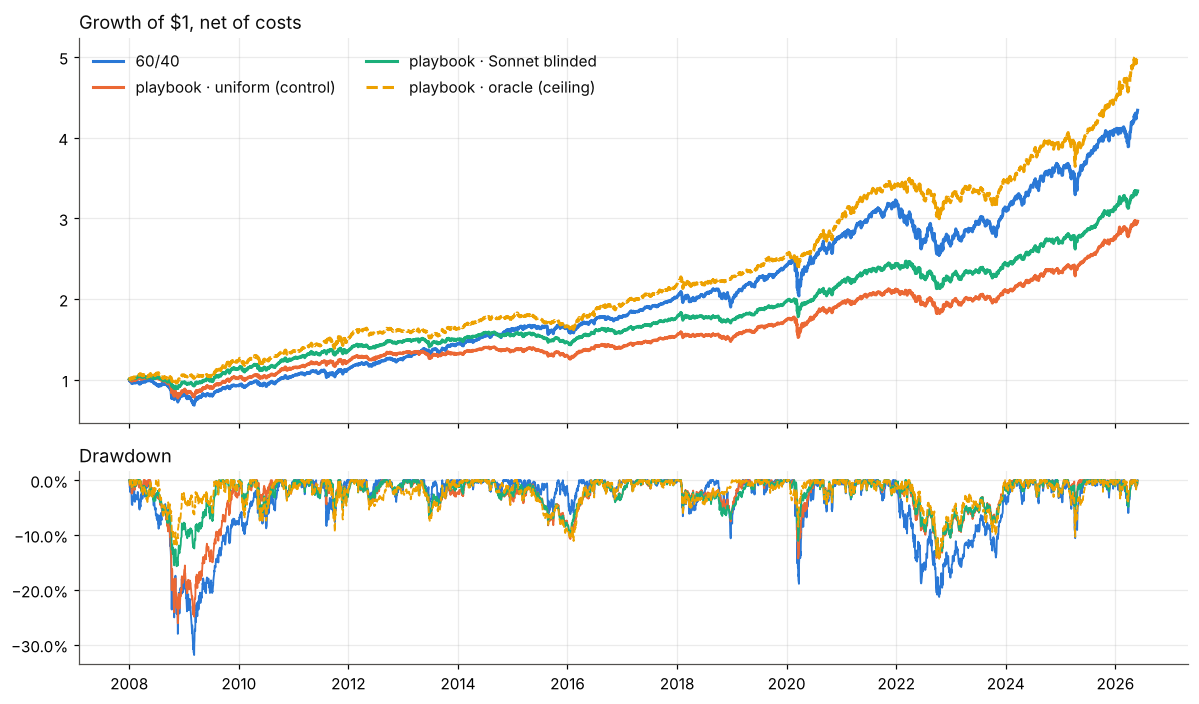

In [3]:
show = [('sixty_forty', '60/40'), ('playbook__uniform', 'playbook · uniform (control)'),
        ('playbook__llm_sonnet_blinded', 'playbook · Sonnet blinded'), ('playbook__oracle', 'playbook · oracle (ceiling)')]
wealth = (1 + daily[[s for s, _ in show]]).cumprod()
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, height_ratios=[2, 1])
for (s, lab), c in zip(show, C):
    ls = '--' if 'oracle' in s else '-'
    a1.plot(wealth.index, wealth[s], color=c, label=lab, linestyle=ls)
    a2.plot(wealth.index, wealth[s] / wealth[s].cummax() - 1, color=c, linewidth=1.2, linestyle=ls)
a1.set_title('Growth of $1, net of costs', loc='left'); a1.legend(frameon=False, ncol=2, loc='upper left')
a2.set_title('Drawdown', loc='left'); a2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
plt.tight_layout(); plt.show()

**Reading.** Playbooks are lower-risk than 60/40 by construction, so compare risk-adjusted: driving the playbook with blinded Sonnet gives a lower return than 60/40 (6.8% vs 8.3% a year) at two-thirds of its volatility and half its drawdown, and sits about halfway between the uniform control and the oracle ceiling. ML GBT on the raw pack lands in the same place. (κ below is shown from 2009-07, when the labelled history used by the pre-registered design starts.)

## 2. Is any of it significant?

Paired comparison on the same months: annualised Sharpe difference, moving-block bootstrap (6-month blocks), 95% CI.

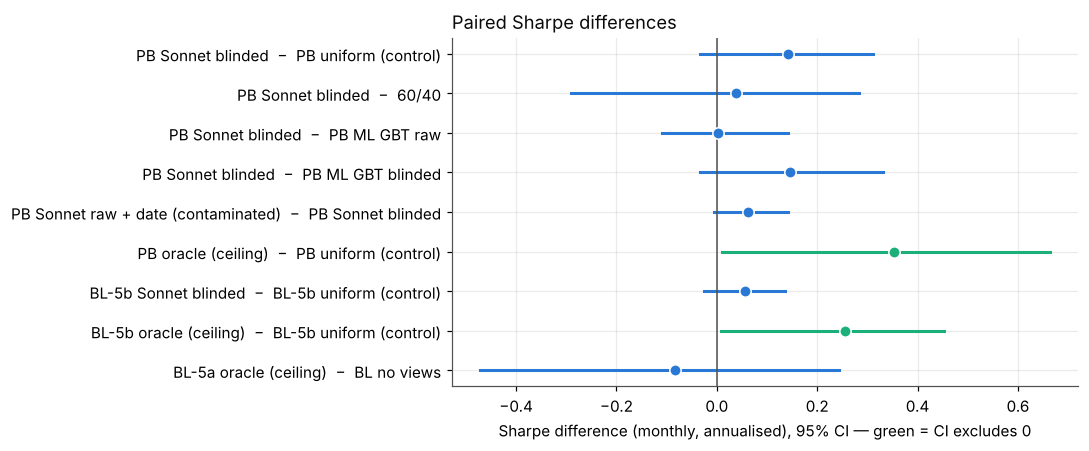

,diff,lo,hi
pair,,,
PB Sonnet blinded − PB uniform (control),0.142,-0.034,0.311
PB Sonnet blinded − 60/40,0.038,-0.291,0.282
PB Sonnet blinded − PB ML GBT raw,0.003,-0.110,0.142
PB Sonnet blinded − PB ML GBT blinded,0.146,-0.034,0.330
PB Sonnet raw + date (contaminated) − PB Sonnet blinded,0.062,-0.005,0.141
PB oracle (ceiling) − PB uniform (control),0.353,0.010,0.663
BL-5b Sonnet blinded − BL-5b uniform (control),0.056,-0.026,0.136
BL-5b oracle (ceiling) − BL-5b uniform (control),0.255,0.007,0.453
BL-5a oracle (ceiling) − BL no views,-0.083,-0.471,0.244


In [4]:
pairs = [('playbook__llm_sonnet_blinded', 'playbook__uniform'), ('playbook__llm_sonnet_blinded', 'sixty_forty'),
         ('playbook__llm_sonnet_blinded', 'playbook__ml_gbt'), ('playbook__llm_sonnet_blinded', 'playbook__ml_gbt_blinded'),
         ('playbook__llm_sonnet_dated', 'playbook__llm_sonnet_blinded'), ('playbook__oracle', 'playbook__uniform'),
         ('bl_playbook__llm_sonnet_blinded', 'bl_playbook__uniform'), ('bl_playbook__oracle', 'bl_playbook__uniform'),
         ('bl_regime__oracle', 'bl_equilibrium')]
def lab(s):
    if '__' not in s: return {'sixty_forty': '60/40', 'bl_equilibrium': 'BL no views'}[s]
    f, k = s.split('__'); return f"{ {'playbook': 'PB', 'bl_playbook': 'BL-5b', 'bl_regime': 'BL-5a'}[f] } {NAMES[k]}"
ci = pd.DataFrame([dict(zip(['diff', 'lo', 'hi'], sharpe_diff_ci(mex[a], mex[b])), pair=f'{lab(a)}  −  {lab(b)}')
                   for a, b in pairs]).set_index('pair')
fig, ax = plt.subplots(figsize=(10, 4.2))
yp = np.arange(len(ci))[::-1]
for y_, (_, r) in zip(yp, ci.iterrows()):
    c = C[2] if r.lo > 0 else C[0]
    ax.plot([r.lo, r.hi], [y_, y_], color=c); ax.scatter(r['diff'], y_, s=55, color=c, edgecolor='white', zorder=3)
ax.axvline(0, color=MUTED, linewidth=1); ax.set_yticks(yp, ci.index)
ax.set_xlabel('Sharpe difference (monthly, annualised), 95% CI — green = CI excludes 0')
ax.set_title('Paired Sharpe differences', loc='left'); plt.tight_layout(); plt.show()
ci.round(3)

**Reading.** Only the oracle clears zero, and only just. With ~220 months, Sharpe differences below about 0.3 cannot be resolved; blinded Sonnet's +0.14 over the control is in the right direction but inside the noise. Telling Sonnet the date buys a little more Sharpe on top — the money value of memory — also not significant.

## 3. Black-Litterman, pre-registered (5a): return-based regime views

Views from historical regime-conditional returns. Views switch on only once 24 labelled months with complete return windows exist (2009-07); before that every 5a strategy is plain BL.

In [5]:
t = family('bl_regime'); t.loc['BL no views (equilibrium)'] = bench.loc['bl_equilibrium']
t.sort_values('sharpe', ascending=False)

,ann_return,ann_vol,sharpe,max_drawdown,turnover_per_year
strategy,,,,,
BL no views (equilibrium),0.068,0.102,0.568,-0.316,0.129
climatology,0.067,0.108,0.537,-0.316,0.413
uniform (control),0.067,0.107,0.534,-0.316,0.411
Sonnet blinded,0.068,0.115,0.517,-0.316,1.494
oracle (ceiling),0.083,0.154,0.510,-0.316,2.796
ML logit raw,0.070,0.133,0.478,-0.316,2.151
ML GBT blinded,0.066,0.133,0.454,-0.316,2.377
Sonnet raw + date (contaminated),0.062,0.121,0.446,-0.316,1.293
Sonnet raw (contaminated),0.062,0.122,0.444,-0.316,1.396


**Reading.** Even the oracle does **worse** than BL without views. The problem is the mapping, not the forecaster: 3-month regime-conditional means of eight assets are noisy, absolute views on all of them push the long-only optimiser into concentrated bets (volatility jumps from ~10% to ~15%). Kept as the pre-registered result.

## 4. Black-Litterman, post-hoc (5b): playbook-implied views

Declared after 5a, one design only, no further variants. Views are the equilibrium returns of the probability-weighted playbook, so BL blends the reference portfolio toward the regime portfolio in proportion to how decisive the forecast is.

In [6]:
t = family('bl_playbook'); t.loc['BL no views (equilibrium)'] = bench.loc['bl_equilibrium']
t.sort_values('sharpe', ascending=False)

,ann_return,ann_vol,sharpe,max_drawdown,turnover_per_year
strategy,,,,,
oracle (ceiling),0.082,0.080,0.863,-0.163,1.173
Sonnet raw + date (contaminated),0.070,0.085,0.683,-0.222,0.303
Sonnet raw (contaminated),0.069,0.087,0.656,-0.241,0.334
ML GBT raw,0.068,0.086,0.654,-0.258,0.741
Sonnet blinded,0.069,0.088,0.649,-0.240,0.356
ML logit raw,0.068,0.088,0.645,-0.260,0.647
ML GBT blinded,0.064,0.090,0.593,-0.298,0.636
ML logit blinded,0.064,0.091,0.588,-0.263,0.722
uniform (control),0.067,0.099,0.576,-0.309,0.132


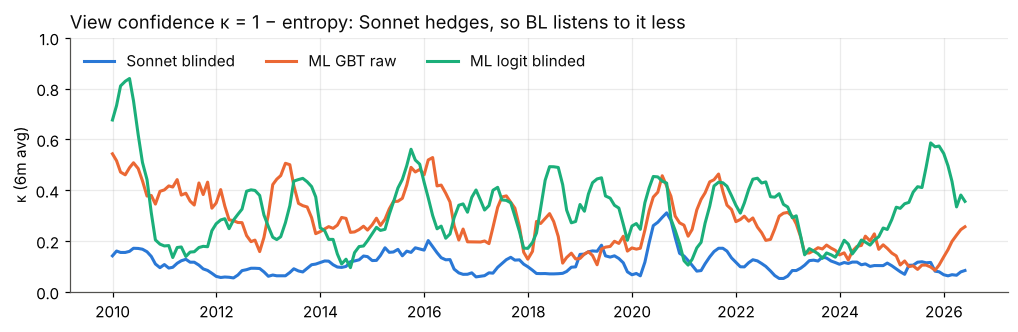

forecaster
llm_sonnet_blinded    0.114
ml_gbt                0.283
ml_logit_blinded      0.327
oracle                1.000
Name: mean κ, dtype: float64

In [7]:
k = views.pivot(index='date', columns='forecaster', values='kappa')
fig, ax = plt.subplots(figsize=(11, 3))
for col, c, lab_ in [('llm_sonnet_blinded', C[0], 'Sonnet blinded'), ('ml_gbt', C[1], 'ML GBT raw'),
                     ('ml_logit_blinded', C[2], 'ML logit blinded')]:
    ax.plot(k.index, k[col].rolling(6).mean(), color=c, label=lab_)
ax.set_ylim(0, 1); ax.set_ylabel('κ (6m avg)')
ax.legend(frameon=False, ncol=3, loc='upper left')
ax.set_title('View confidence κ = 1 − entropy: Sonnet hedges, so BL listens to it less', loc='left')
plt.show()
k[['llm_sonnet_blinded', 'ml_gbt', 'ml_logit_blinded', 'oracle']].mean().round(3).rename('mean κ')

**Reading.** The mapping now works (oracle ≈ +0.3 Sharpe over plain BL). Blinded Sonnet improves on the control with less drawdown, but its probabilities are diffuse (κ ≈ 0.11 vs ~0.3 for ML), so the tilts are small. It also trades about half as much as the ML-driven BL.

## 5. Costs

Sharpe at 0 / 2.5 / 5 / 10 bps on traded notional.

In [8]:
keys = ['sixty_forty', 'bl_equilibrium', 'playbook__uniform', 'playbook__llm_sonnet_blinded', 'playbook__ml_gbt',
        'bl_playbook__llm_sonnet_blinded', 'bl_playbook__ml_gbt', 'playbook__oracle']
s = met[met.strategy.isin(keys)].pivot(index='strategy', columns='cost_bps', values='sharpe').loc[keys]
s.columns = [f'{c:g} bps' for c in s.columns]
s.index = [lab(i) for i in s.index]
s.round(3)

,0 bps,2.5 bps,5 bps,10 bps
60/40,0.656,0.655,0.655,0.654
BL no views,0.569,0.568,0.568,0.566
PB uniform (control),0.611,0.610,0.609,0.608
PB Sonnet blinded,0.762,0.756,0.750,0.738
PB ML GBT raw,0.762,0.752,0.742,0.722
BL-5b Sonnet blinded,0.651,0.649,0.647,0.643
BL-5b ML GBT raw,0.658,0.654,0.649,0.641
PB oracle (ceiling),0.972,0.961,0.950,0.928


**Reading.** Rankings are stable across cost levels: monthly turnover here is ~0.4–1.5× a year, so even 10 bps costs at most a few hundredths of Sharpe.

## What we can and cannot claim

* **Regime information is worth having, if mapped simply.** With perfect foresight a plain playbook reaches Sharpe ≈ 0.96 vs 0.61 for the uniform control; return-based BL views (5a) throw that away.
* **Blinded Sonnet captures part of it.** Playbook Sharpe 0.76 with −16% max drawdown (60/40: 0.66, −32%), about halfway from control to ceiling — and no better than ML GBT on the raw pack.
* **Nothing short of the oracle is statistically distinguishable** from the control on ~18 years of monthly data. The allocation results are consistent with nb02's forecast skill, not independent proof of it.
* **5b is post-hoc** and labelled as such everywhere; its parameters were not tuned.
* **Caveats.** One LLM run per variant; playbooks and reference set once, ex ante; a single path dominated by 2008, 2020 and 2022.

**Next (Phase 7):** a prospective log — one blinded Sonnet call per month from here on, committed before the outcome is known. It is the only test the model's memory cannot touch.